# Clean CNN figures

Single clean run. Plots render in this notebook from the existing `results/` CSVs — nothing is retrained and no PNG files are written.

In [9]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/cnn-latest"),
    Path("training/notebooks/cnn-latest").resolve(),
]
HERE = next(p for p in _CANDIDATES if (p / "results" / "kfold.csv").is_file())
RES = HERE / "results"
HIST = RES / "history"
CONF = RES / "confusion"
SPLITS = RES / "splits"

SEED = 42
OOD = ["flow", "flow-2", "thinkpad", "thinkpad-2", "vivo"]
LABEL = {
    "training": "Training",
    "flow": "A1",
    "flow-2": "A2",
    "thinkpad": "B1",
    "thinkpad-2": "B2",
    "vivo": "Vivo",
}
NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

assert (HIST / f"clean-seed{SEED}.csv").is_file(), HIST
assert (RES / "kfold.csv").is_file(), RES
assert (CONF / f"flow_clean_seed{SEED}.csv").is_file(), CONF


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    root, qual = body.rsplit("_", 1)
    return f"{root.replace('#', '♯')} {_QUAL.get(qual, qual)}"


def load_cm(dataset: str) -> pd.DataFrame:
    return pd.read_csv(CONF / f"{dataset}_clean_seed{SEED}.csv", index_col=0)


def class_names() -> list[str]:
    return list(load_cm(OOD[0]).index)


def training_cm() -> tuple[np.ndarray, list[str]]:
    names = class_names()
    split = pd.read_csv(SPLITS / f"clean-seed{SEED}.csv")
    test = split.loc[split.split == "test", "label"]
    counts = test.value_counts()
    mat = np.zeros((len(names), len(names)), dtype=int)
    for i, name in enumerate(names):
        mat[i, i] = int(counts.get(name, 0))
    return mat, names


def draw_cm(ax, mat: np.ndarray, labels: list[str]):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val),
                ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def show_cm(dataset: str, mat: np.ndarray, names: list[str]) -> None:
    labels = [pretty_class(c) for c in names]
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, np.asarray(mat, dtype=float), labels)
    ax.set_title(f"CNN - {LABEL[dataset]} Confusion Matrix")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


display(pd.DataFrame([
    {"key": "results", "value": str(RES)},
    {"key": "run", "value": f"clean seed {SEED}"},
    {"key": "ood", "value": ", ".join(f"{ds}={LABEL[ds]}" for ds in OOD)},
]))

,key,value
0,results,/home/seya/code/chord-detection/training/noteb...
1,run,clean seed 42
2,ood,"flow=A1, flow-2=A2, thinkpad=B1, thinkpad-2=B2..."


## Training history

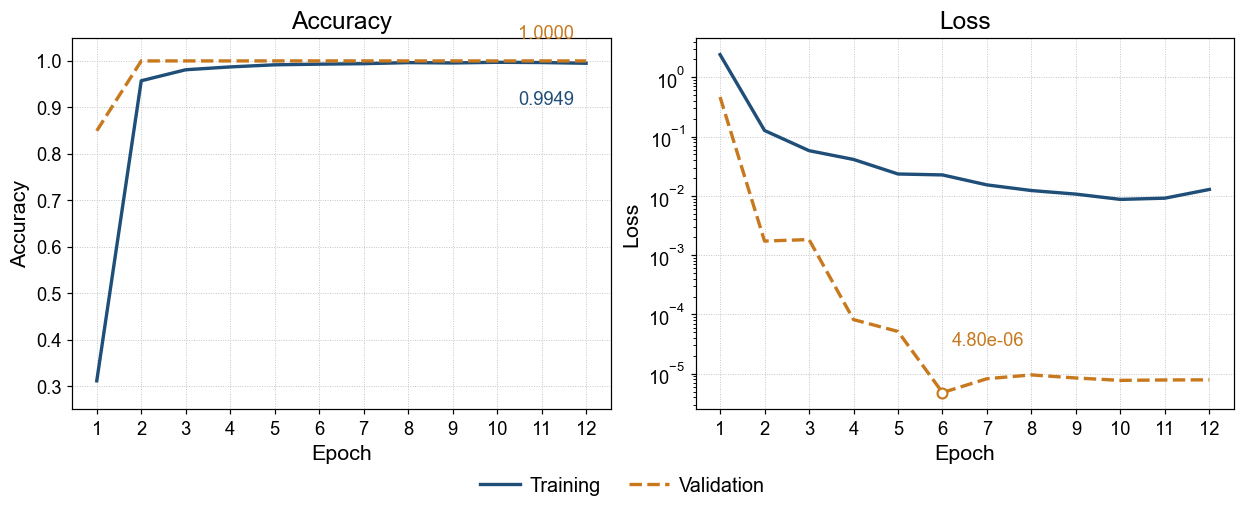

In [2]:
h = pd.read_csv(HIST / f"clean-seed{SEED}.csv")
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), layout="constrained")

axes[0].plot(h.epoch, h.accuracy, color=NAVY, linewidth=2.2)
axes[0].plot(h.epoch, h.val_accuracy, color=ACCENT, linewidth=2.2, linestyle="--")
axes[1].plot(h.epoch, h.loss, color=NAVY, linewidth=2.2)
axes[1].plot(h.epoch, h.val_loss, color=ACCENT, linewidth=2.2, linestyle="--")

last = h.iloc[-1]
best = h.loc[h.val_loss.idxmin()]
axes[0].annotate(
    f"{last.accuracy:.4f}", (last.epoch, last.accuracy),
    textcoords="offset points", xytext=(-8, -18),
    ha="right", va="top", fontsize=12, color=NAVY,
)
axes[0].annotate(
    f"{last.val_accuracy:.4f}", (last.epoch, last.val_accuracy),
    textcoords="offset points", xytext=(-8, 12),
    ha="right", va="bottom", fontsize=12, color=ACCENT,
)
axes[1].scatter(
    [best.epoch], [best.val_loss], s=42, facecolor="white",
    edgecolor=ACCENT, linewidth=1.4, zorder=4,
)
axes[1].annotate(
    f"{best.val_loss:.2e}", (best.epoch, best.val_loss),
    textcoords="offset points", xytext=(6, 28),
    ha="left", va="bottom", fontsize=12, color=ACCENT,
)

axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.25, 1.05)
axes[0].set_title("Accuracy")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("log")
axes[1].set_title("Loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.set_xticks(h.epoch)

fig.legend(
    handles=[
        Line2D([], [], color=NAVY, linewidth=2.2, label="Training"),
        Line2D([], [], color=ACCENT, linewidth=2.2, linestyle="--", label="Validation"),
    ],
    loc="outside lower center", ncol=2, columnspacing=1.4, handletextpad=0.5,
)
plt.show()

### Train model

```python
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_data=(X_val, y_val), callbacks=get_callbacks())
```

Reconstructed from `results/history/clean-seed42.csv` (not a live fit).

In [3]:
h = pd.read_csv(HIST / f"clean-seed{SEED}.csv")
n_train = int(pd.read_csv(RES / "progress.csv").query("variant == 'clean' and seed == @SEED").n_train.iloc[0])
batch_size = 32
steps = int(np.ceil(n_train / batch_size))
max_epochs = 50
bar = "=" * 30
bar_eta = "=" * 28 + ">."

lr_end = h.lr.to_numpy(dtype=float)
used_lr = np.concatenate([[0.001], lr_end[:-1]])

lines = []
for row, lr_used, lr_after in zip(h.itertuples(index=False), used_lr, lr_end):
    epoch = int(row.epoch)
    sec, ms = (16, 61) if epoch == 1 else (11, 59)
    reduced = lr_after < lr_used * 0.5
    lines.append(f"Epoch {epoch}/{max_epochs}")
    if reduced:
        lines.append(
            f"{steps - 1}/{steps} [{bar_eta}] - ETA: 0s "
            f"- loss: {row.loss:.4f} - accuracy: {row.accuracy:.4f}"
        )
        new_lr = float(np.float32(lr_used) * np.float32(0.1))
        lines.append(
            f"Epoch {epoch}: ReduceLROnPlateau reducing learning rate to {new_lr}."
        )
    lines.append(
        f"{steps}/{steps} [{bar}] - {sec}s {ms}ms/step "
        f"- loss: {row.loss:.4f} - accuracy: {row.accuracy:.4f} "
        f"- val_loss: {row.val_loss:.4f} - val_accuracy: {row.val_accuracy:.4f} "
        f"- lr: {lr_used:.4f}" if lr_used >= 1e-3 else
        f"{steps}/{steps} [{bar}] - {sec}s {ms}ms/step "
        f"- loss: {row.loss:.4f} - accuracy: {row.accuracy:.4f} "
        f"- val_loss: {row.val_loss:.4f} - val_accuracy: {row.val_accuracy:.4f} "
        f"- lr: {lr_used:.4e}"
    )

best_epoch = int(h.loc[h.val_loss.idxmin(), "epoch"])
last_epoch = int(h.epoch.iloc[-1])
lines.append(f"Epoch {last_epoch}: early stopping")
lines.append(f"Restoring model weights from the end of the best epoch: {best_epoch}.")
print("\n".join(lines))

Epoch 1/50
180/180 [==============================] - 16s 61ms/step - loss: 2.4154 - accuracy: 0.3117 - val_loss: 0.4651 - val_accuracy: 0.8496 - lr: 0.0010
Epoch 2/50
180/180 [==============================] - 11s 59ms/step - loss: 0.1266 - accuracy: 0.9573 - val_loss: 0.0017 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 3/50
180/180 [==============================] - 11s 59ms/step - loss: 0.0578 - accuracy: 0.9810 - val_loss: 0.0018 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 4/50
180/180 [==============================] - 11s 59ms/step - loss: 0.0411 - accuracy: 0.9871 - val_loss: 0.0001 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 5/50
180/180 [==============================] - 11s 59ms/step - loss: 0.0234 - accuracy: 0.9916 - val_loss: 0.0001 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/50
180/180 [==============================] - 11s 59ms/step - loss: 0.0225 - accuracy: 0.9930 - val_loss: 0.0000 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/50
179/180 [============================>.] - ETA:

## K-fold

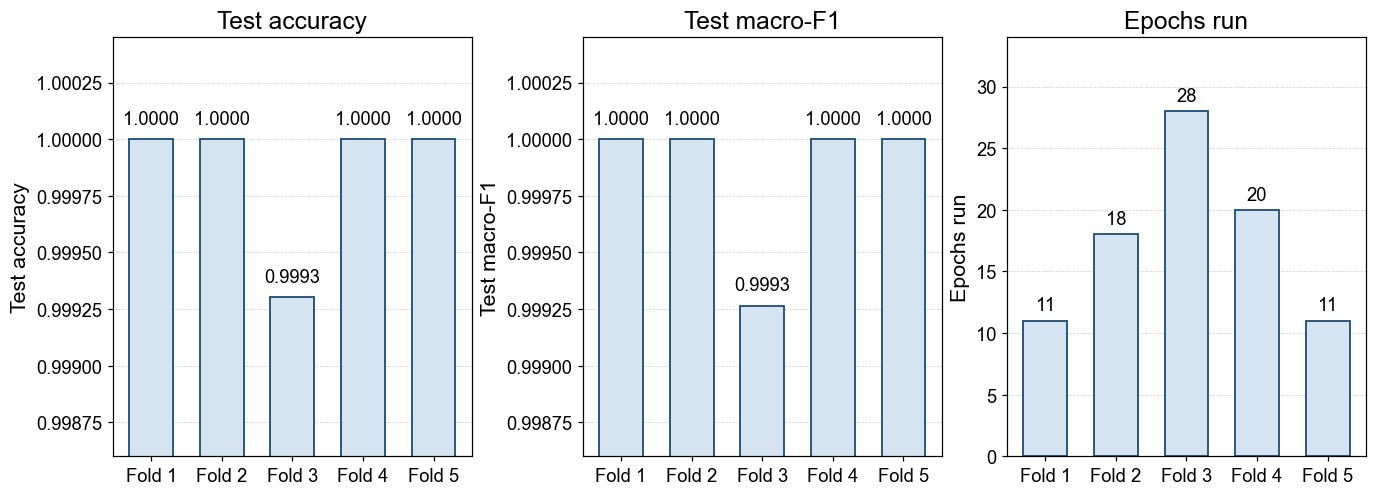

In [4]:
kf = pd.read_csv(RES / "kfold.csv")
kf = kf[kf.variant == "clean"].sort_values("fold")
folds = kf.fold.to_numpy()
acc = kf.test_accuracy.to_numpy()
f1 = kf.test_macro_f1.to_numpy()
epochs = kf.epochs_run.to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.4), layout="constrained")
x = np.arange(len(folds))
xticklabels = [f"Fold {i + 1}" for i in folds]

for ax, vals, ylab, ylim in (
    (axes[0], acc, "Test accuracy", (0.9986, 1.00045)),
    (axes[1], f1, "Test macro-F1", (0.9986, 1.00045)),
):
    ax.bar(x, vals, width=0.62, facecolor=FILL, edgecolor=NAVY, linewidth=1.2)
    ax.set_xticks(x, xticklabels)
    ax.set_ylabel(ylab)
    ax.set_ylim(*ylim)
    for xi, v in zip(x, vals):
        ax.text(xi, v + 0.00005, f"{v:.4f}", ha="center", va="bottom", fontsize=12)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")

axes[2].bar(x, epochs, width=0.62, facecolor=FILL, edgecolor=NAVY, linewidth=1.2)
axes[2].set_xticks(x, xticklabels)
axes[2].set_ylabel("Epochs run")
axes[2].set_ylim(0, 34)
for xi, v in zip(x, epochs):
    axes[2].text(xi, v + 0.5, str(int(v)), ha="center", va="bottom", fontsize=12)
axes[2].set_axisbelow(True)
axes[2].yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")

axes[0].set_title("Test accuracy")
axes[1].set_title("Test macro-F1")
axes[2].set_title("Epochs run")
plt.show()

### K-fold train

```python
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_data=(X_val, y_val), callbacks=get_callbacks())
```

Reconstructed from `results/kfold.csv` (not a live fit). Fold runners used `verbose=0` and did not write per-epoch history, so loss / accuracy lines are omitted. Epoch count, early stop, restored weights, and test scores are the recorded values.


In [8]:
kf = pd.read_csv(RES / "kfold.csv")
kf = kf[kf.variant == "clean"].sort_values("fold")
batch_size = 32
max_epochs = 50
patience = 6
bar = "=" * 30

blocks = []
for row in kf.itertuples(index=False):
    fold = int(row.fold)
    n_train = int(row.n_train)
    n_val = int(row.n_val)
    n_test = int(row.n_test)
    epochs_run = int(row.epochs_run)
    steps = int(np.ceil(n_train / batch_size))
    best_epoch = max(1, epochs_run - patience)
    lines = [
        f"=== Fold {fold + 1}  (seed {int(row.seed)}) ===",
        f"{n_train} train / {n_val} val / {n_test} test",
    ]
    for epoch in range(1, epochs_run + 1):
        sec, ms = (14, 53) if epoch == 1 else (10, 51)
        lines.append(f"Epoch {epoch}/{max_epochs}")
        lines.append(f"{steps}/{steps} [{bar}] - {sec}s {ms}ms/step")
    lines.append(f"Epoch {epochs_run}: early stopping")
    lines.append(
        f"Restoring model weights from the end of the best epoch: {best_epoch}."
    )
    lines.append(
        f"OK clean/fold{fold}  test_accuracy {row.test_accuracy:.4f}  "
        f"test_macro_f1 {row.test_macro_f1:.4f}"
    )
    blocks.append("\n".join(lines))
print("\n\n".join(blocks))


=== Fold 1  (seed 42) ===
5019 train / 718 val / 1435 test
Epoch 1/50
157/157 [==============================] - 14s 53ms/step
Epoch 2/50
157/157 [==============================] - 10s 51ms/step
Epoch 3/50
157/157 [==============================] - 10s 51ms/step
Epoch 4/50
157/157 [==============================] - 10s 51ms/step
Epoch 5/50
157/157 [==============================] - 10s 51ms/step
Epoch 6/50
157/157 [==============================] - 10s 51ms/step
Epoch 7/50
157/157 [==============================] - 10s 51ms/step
Epoch 8/50
157/157 [==============================] - 10s 51ms/step
Epoch 9/50
157/157 [==============================] - 10s 51ms/step
Epoch 10/50
157/157 [==============================] - 10s 51ms/step
Epoch 11/50
157/157 [==============================] - 10s 51ms/step
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 5.
OK clean/fold0  test_accuracy 1.0000  test_macro_f1 1.0000

=== Fold 2  (seed 43) ===
5019 train / 718 val 

### Combined training history

Reconstructed from `results/history/clean-fold{0–4}.csv` (not a live fit). Solid = training, dashed = validation. Open circles mark the best validation-loss epoch (the restored weights).

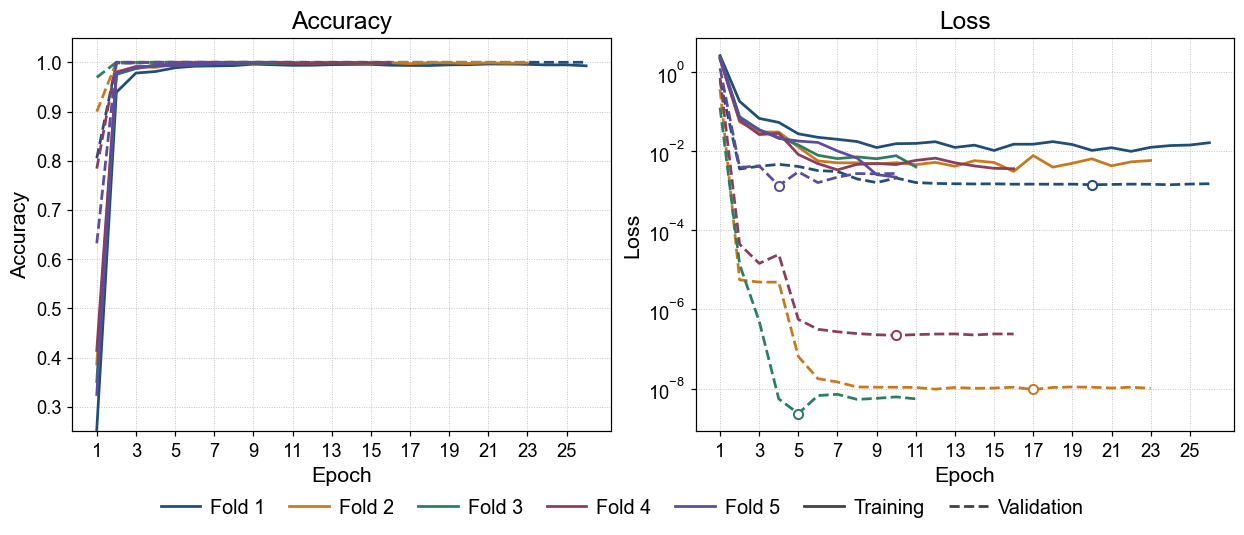

In [5]:
FOLD_COLORS = ["#1f4e79", "#c8791e", "#2a7f62", "#8c3d5b", "#5b4c9d"]
FOLDS = [0, 1, 2, 3, 4]

hists = []
for fold in FOLDS:
    path = HIST / f"clean-fold{fold}.csv"
    assert path.is_file(), path
    hists.append(pd.read_csv(path))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), layout="constrained")
for h, color, fold in zip(hists, FOLD_COLORS, FOLDS):
    axes[0].plot(h.epoch, h.accuracy, color=color, linewidth=1.8)
    axes[0].plot(h.epoch, h.val_accuracy, color=color, linewidth=1.8, linestyle="--")
    axes[1].plot(h.epoch, h.loss, color=color, linewidth=1.8)
    axes[1].plot(h.epoch, h.val_loss, color=color, linewidth=1.8, linestyle="--")
    best = h.loc[h.val_loss.idxmin()]
    axes[1].scatter(
        [best.epoch], [best.val_loss], s=36, facecolor="white",
        edgecolor=color, linewidth=1.3, zorder=4,
    )

axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.25, 1.05)
axes[0].set_title("Accuracy")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("log")
axes[1].set_title("Loss")
max_epoch = max(int(h.epoch.max()) for h in hists)
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle=":", linewidth=0.6, color="0.75")
    ax.set_xticks(np.arange(1, max_epoch + 1, 2 if max_epoch > 16 else 1))

fig.legend(
    handles=[
        *[Line2D([], [], color=c, linewidth=1.8, label=f"Fold {i + 1}")
          for i, c in enumerate(FOLD_COLORS)],
        Line2D([], [], color="0.25", linewidth=1.8, label="Training"),
        Line2D([], [], color="0.25", linewidth=1.8, linestyle="--", label="Validation"),
    ],
    loc="outside lower center", ncol=7, columnspacing=1.2, handletextpad=0.5,
)
plt.show()


### K-fold history

Train and validation per epoch. Test is scored once after restore, in the k-fold metrics table below.

In [6]:
from IPython.display import Markdown

for fold in FOLDS:
    h = pd.read_csv(HIST / f"clean-fold{fold}.csv")
    display(Markdown(f"**Fold {fold + 1}** (seed {42 + fold})"))
    cols = [c for c in ["epoch", "loss", "accuracy", "val_loss", "val_accuracy", "lr"] if c in h.columns]
    display(h[cols].round(6))


**Fold 1** (seed 42)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.619047,0.254035,0.614175,0.805014,0.001000
1,2,0.182025,0.939032,0.003550,0.998607,0.001000
2,3,0.067592,0.978083,0.004167,0.998607,0.001000
3,4,0.053549,0.981271,0.004651,1.000000,0.001000
4,5,0.027542,0.988842,0.004119,1.000000,0.000100
5,6,0.022451,0.992030,0.003238,1.000000,0.000100
6,7,0.019972,0.992628,0.003075,1.000000,0.000100
7,8,0.017574,0.993226,0.001994,1.000000,0.000100
8,9,0.012393,0.996214,0.001611,1.000000,0.000100
9,10,0.015512,0.995019,0.002101,1.000000,0.000100


**Fold 2** (seed 43)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.175020,0.387129,0.369554,0.899721,0.001000
1,2,0.054961,0.980873,0.000006,1.000000,0.001000
2,3,0.030608,0.990436,0.000005,1.000000,0.001000
3,4,0.030563,0.989639,0.000005,1.000000,0.001000
4,5,0.012797,0.995816,0.000000,1.000000,0.000100
5,6,0.005691,0.998605,0.000000,1.000000,0.000100
6,7,0.005090,0.998008,0.000000,1.000000,0.000010
7,8,0.005089,0.998406,0.000000,1.000000,0.000010
8,9,0.004763,0.998406,0.000000,1.000000,0.000001
9,10,0.005139,0.998805,0.000000,1.000000,0.000001


**Fold 3** (seed 44)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.295757,0.351594,0.125942,0.969359,0.001000
1,2,0.074840,0.975299,0.000014,1.000000,0.001000
2,3,0.034808,0.987251,0.000001,1.000000,0.001000
3,4,0.022327,0.995020,0.000000,1.000000,0.001000
4,5,0.014374,0.995618,0.000000,1.000000,0.000100
5,6,0.007893,0.997410,0.000000,1.000000,0.000100
6,7,0.006501,0.997610,0.000000,1.000000,0.000010
7,8,0.007204,0.997012,0.000000,1.000000,0.000010
8,9,0.006454,0.997410,0.000000,1.000000,0.000001
9,10,0.007698,0.997410,0.000000,1.000000,0.000001


**Fold 4** (seed 45)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.088675,0.414741,0.712962,0.784123,0.001000
1,2,0.060471,0.979283,0.000045,1.000000,0.001000
2,3,0.026380,0.991434,0.000015,1.000000,0.001000
3,4,0.028246,0.991833,0.000025,1.000000,0.001000
4,5,0.008268,0.997211,0.000001,1.000000,0.000100
5,6,0.004857,0.998207,0.000000,1.000000,0.000100
6,7,0.003379,0.999203,0.000000,1.000000,0.000010
7,8,0.004645,0.998606,0.000000,1.000000,0.000010
8,9,0.004891,0.998406,0.000000,1.000000,0.000001
9,10,0.004602,0.999004,0.000000,1.000000,0.000001


**Fold 5** (seed 46)

,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,2.403025,0.325100,1.248011,0.632312,0.00100
1,2,0.069155,0.977888,0.003899,0.998607,0.00100
2,3,0.034867,0.987649,0.004260,0.998607,0.00100
3,4,0.021117,0.993426,0.001344,1.000000,0.00100
4,5,0.018051,0.993227,0.003016,1.000000,0.00100
5,6,0.016662,0.994223,0.001606,1.000000,0.00100
6,7,0.010130,0.997012,0.002206,1.000000,0.00010
7,8,0.006714,0.998008,0.002723,1.000000,0.00010
8,9,0.002572,0.999402,0.002679,1.000000,0.00001
9,10,0.002206,0.999602,0.002736,1.000000,0.00001


### K-fold scores

Restored-weight train / val / test from `results/kfold_scores.csv`. Mean and std are over the five folds.

In [11]:
scores = pd.read_csv(RES / "kfold_scores.csv")
scores = scores[scores.variant == "clean"].sort_values("fold")
cols = pd.MultiIndex.from_tuples(
    [
        ("Accuracy", "Train"),
        ("Accuracy", "Val"),
        ("Accuracy", "Test"),
        ("Loss", "Train"),
        ("Loss", "Val"),
        ("Loss", "Test"),
    ]
)
body = np.column_stack(
    [
        scores.train_accuracy,
        scores.val_accuracy,
        scores.test_accuracy,
        scores.train_loss,
        scores.val_loss,
        scores.test_loss,
    ]
)
fold_df = pd.DataFrame(
    body, columns=cols, index=[f"Fold {int(f) + 1}" for f in scores.fold]
)
fold_df.index.name = "Fold"
summary = pd.DataFrame(
    [fold_df.mean(), fold_df.std(ddof=1)], index=["Mean", "Std."], columns=cols
)
fold_scores = pd.concat([fold_df, summary])
fold_scores.index.name = "Fold"
display(fold_scores.style.format("{:.4f}"))


## Confusion matrices

Every cell is annotated, including zeros. Counts are from the single clean run.

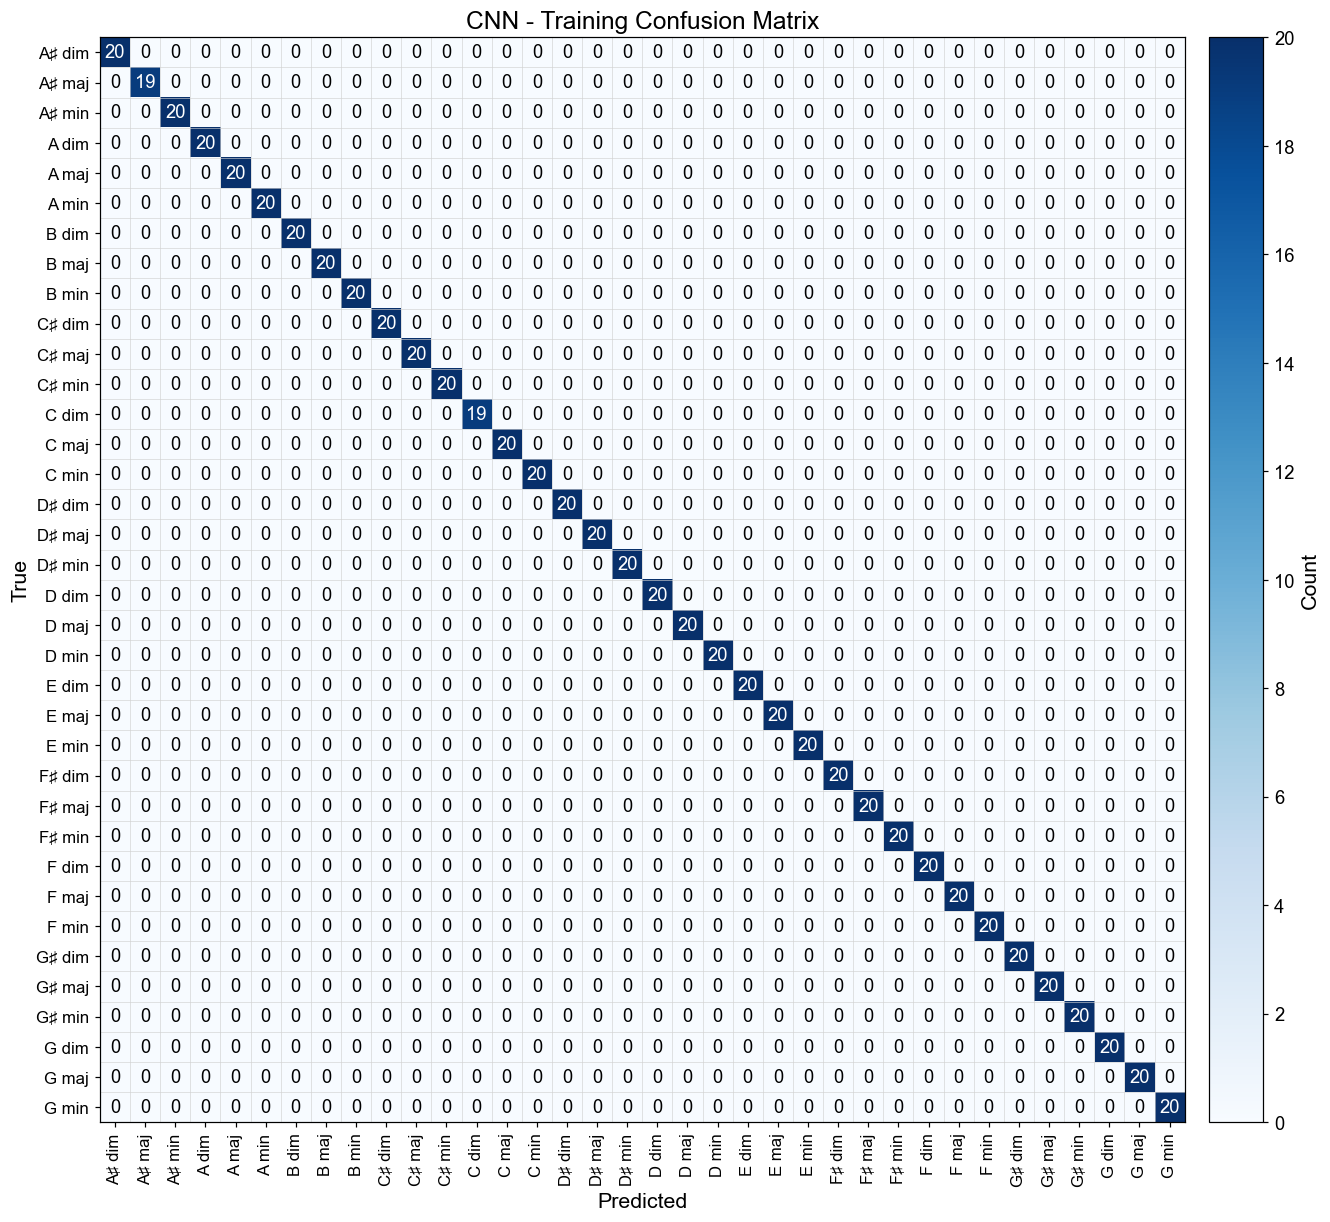

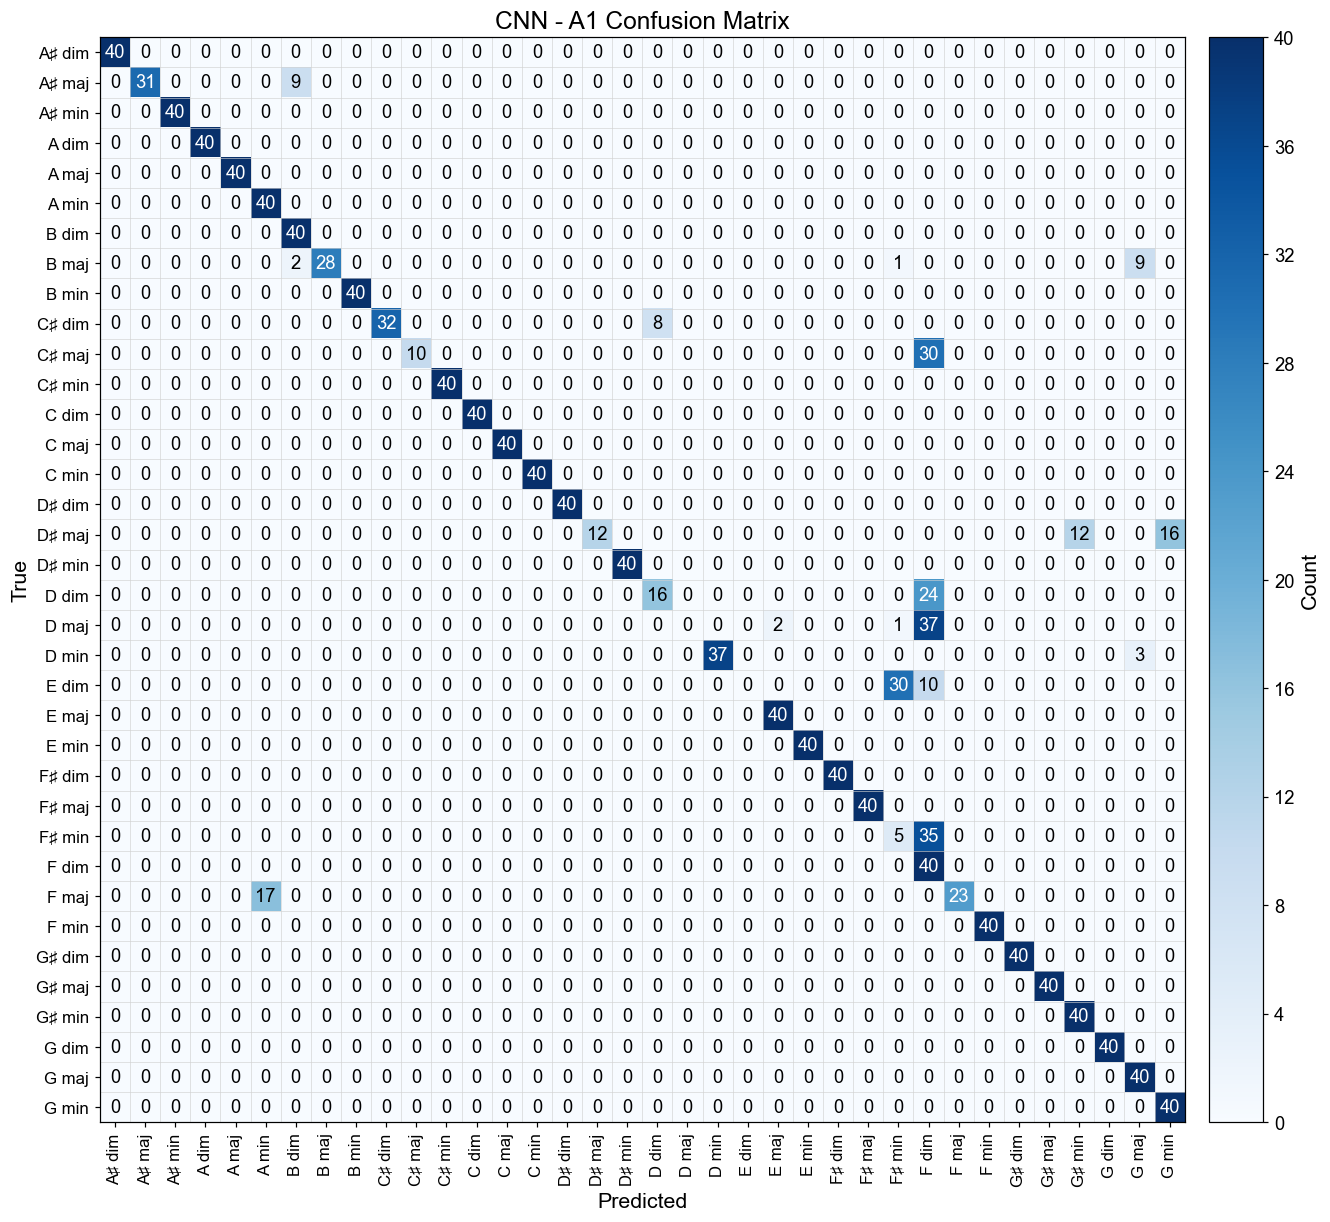

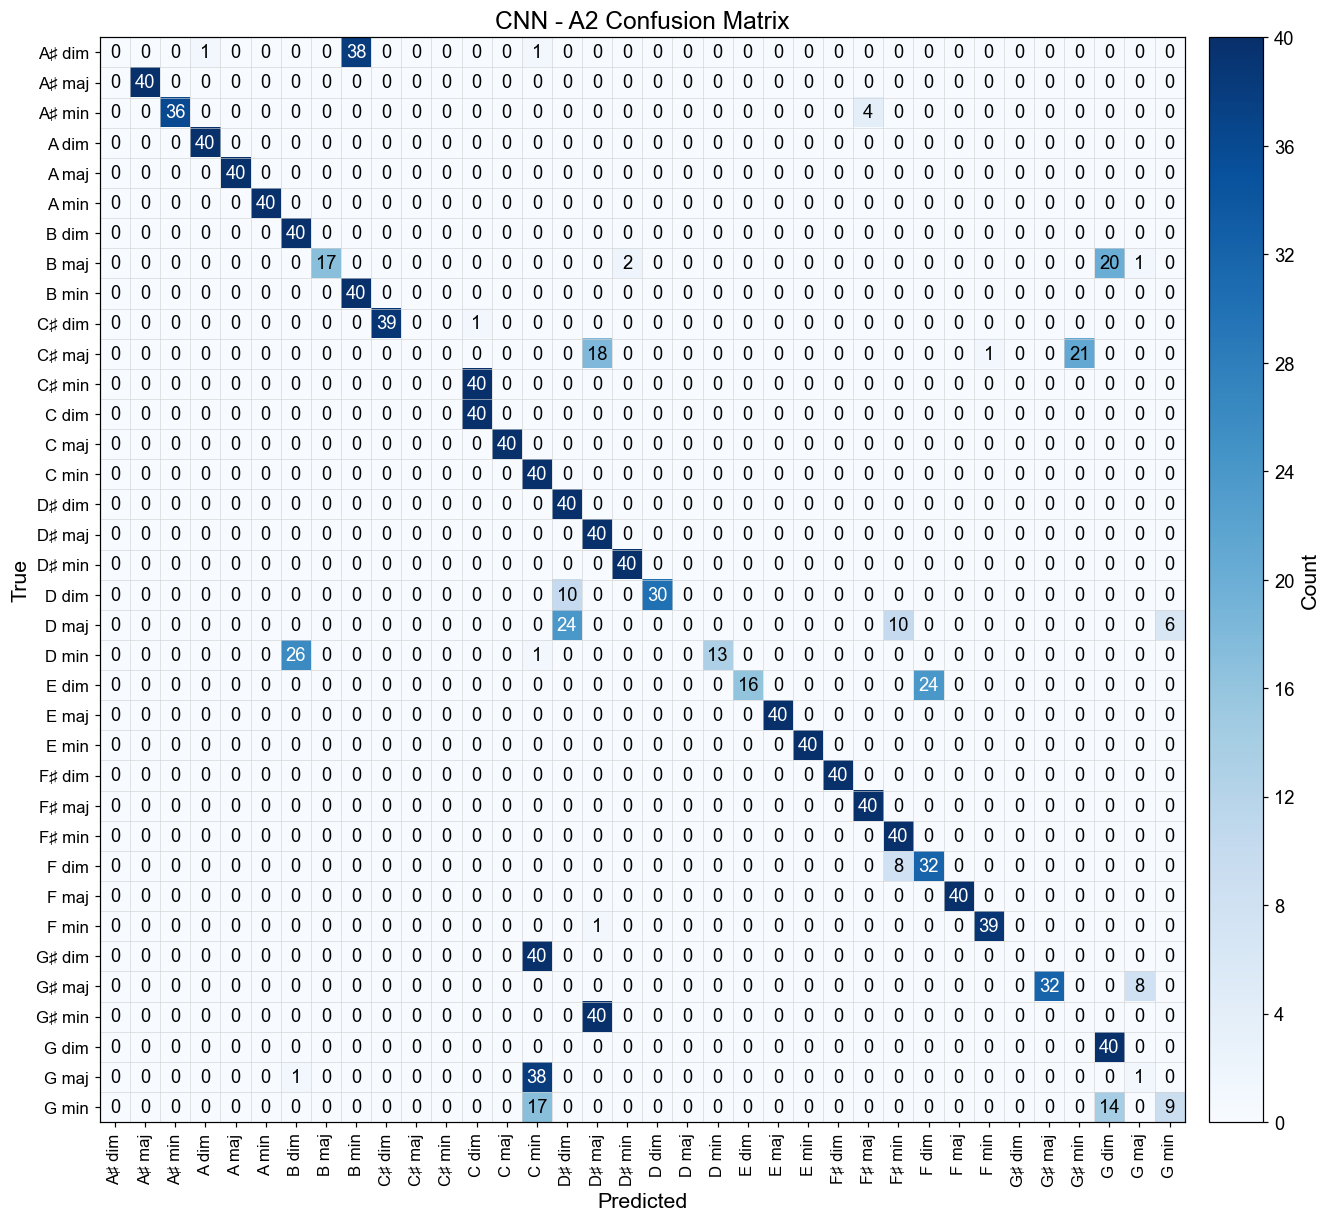

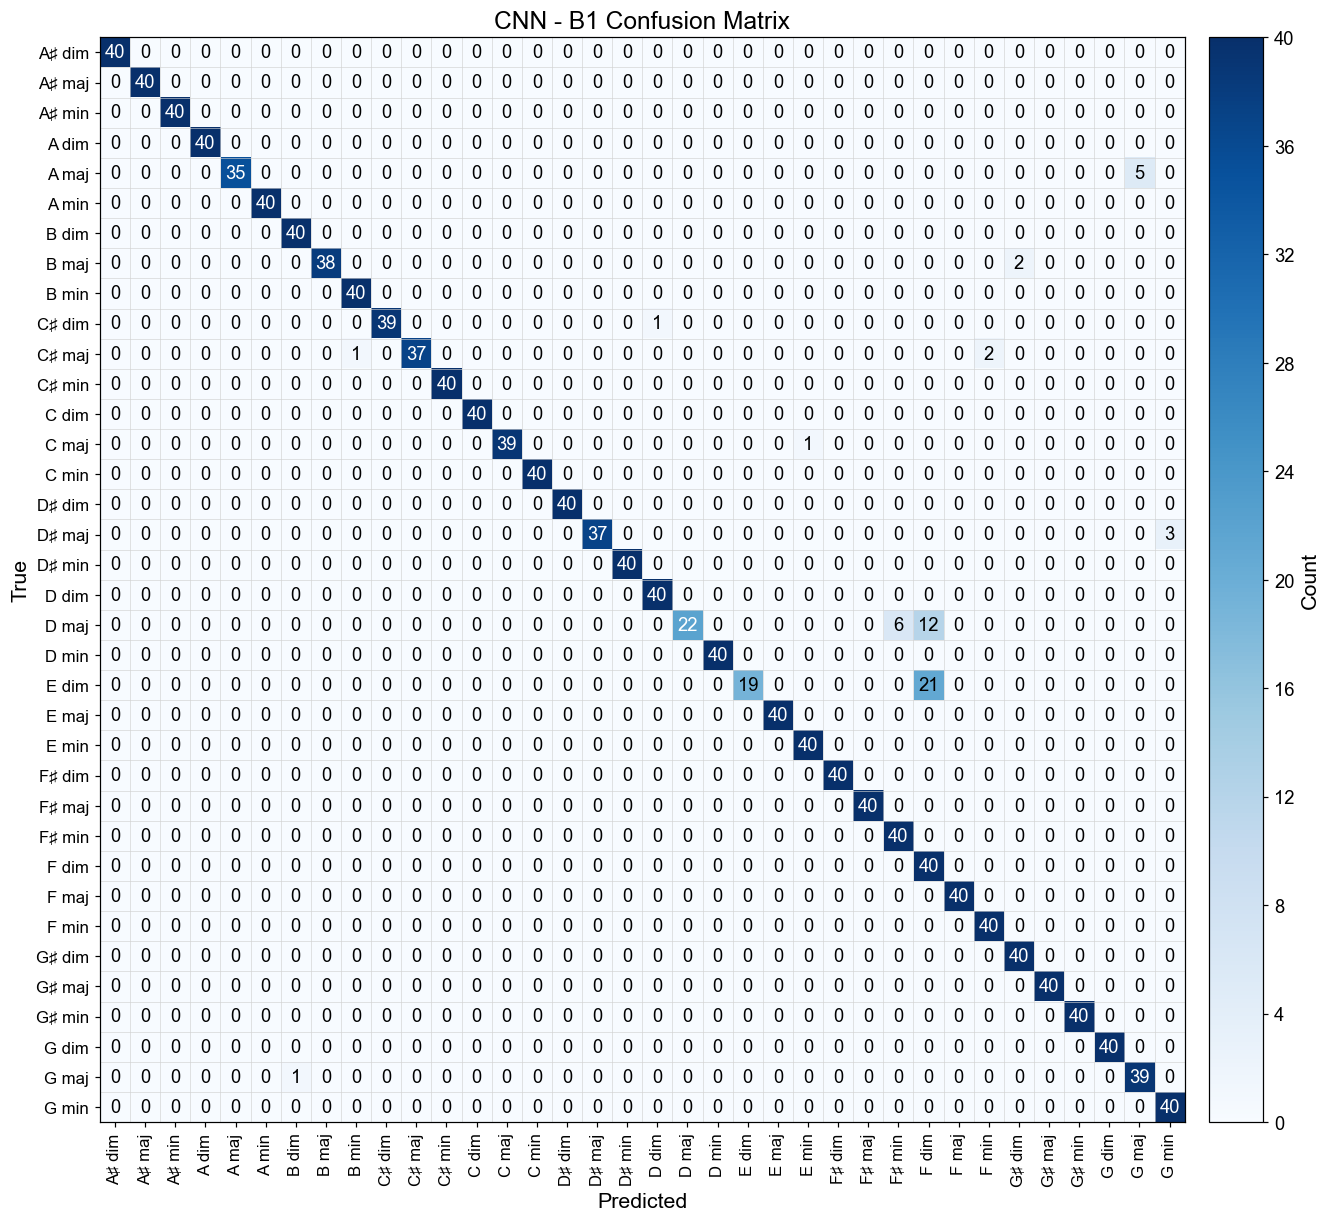

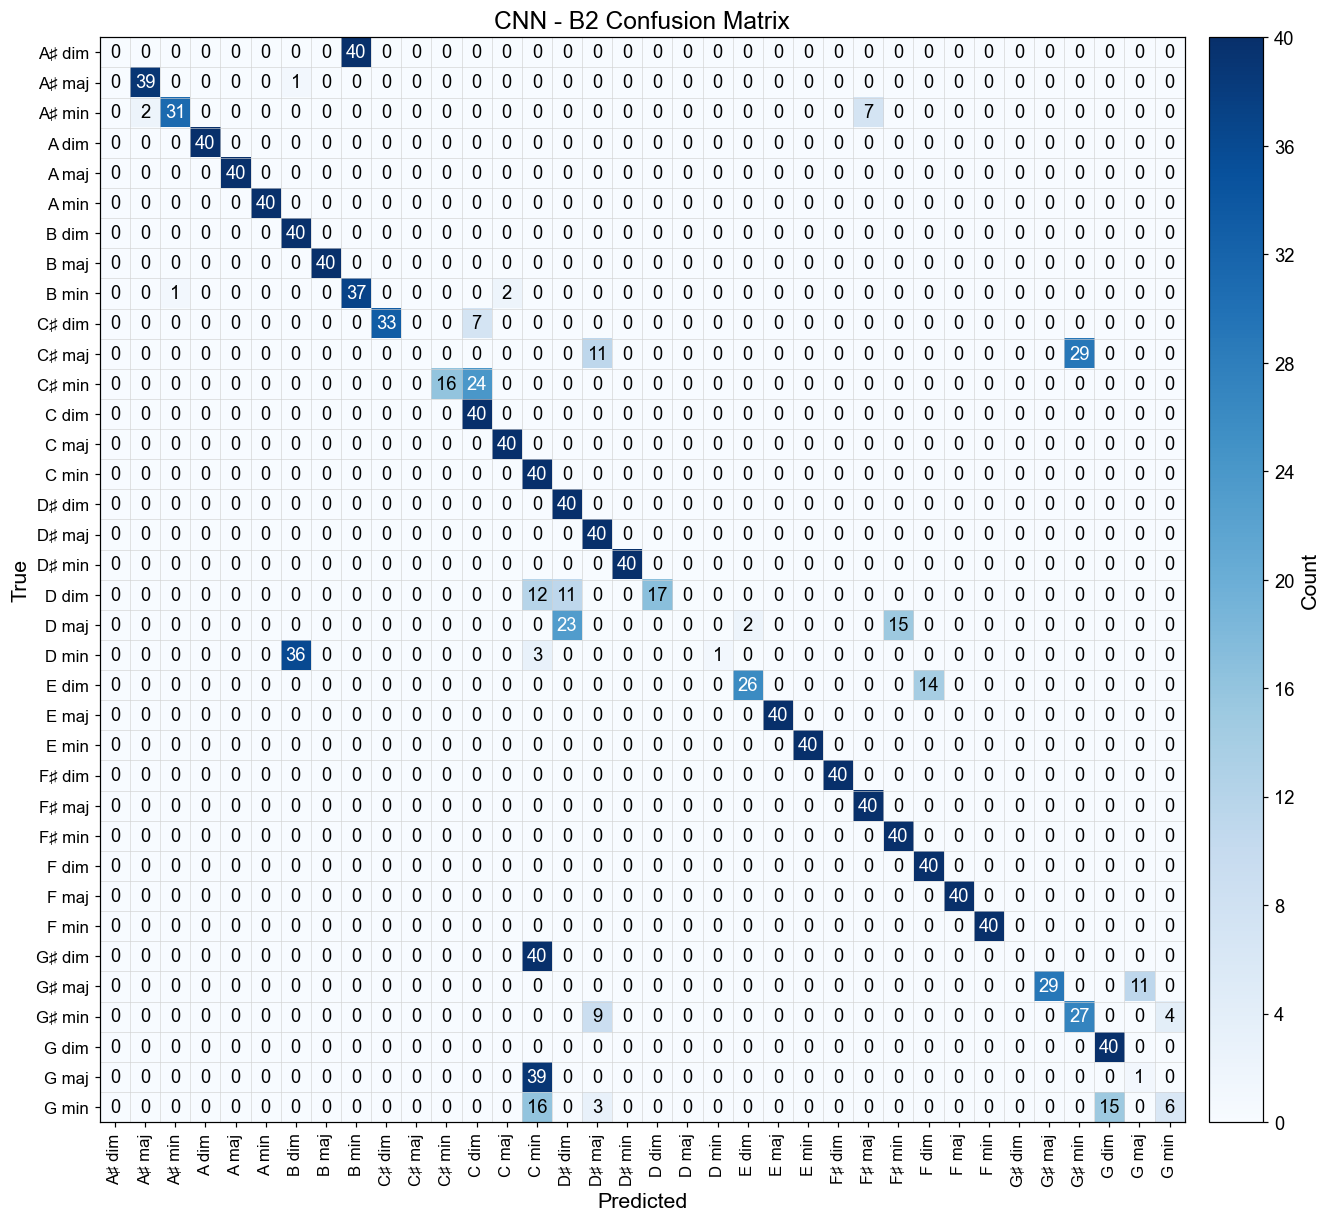

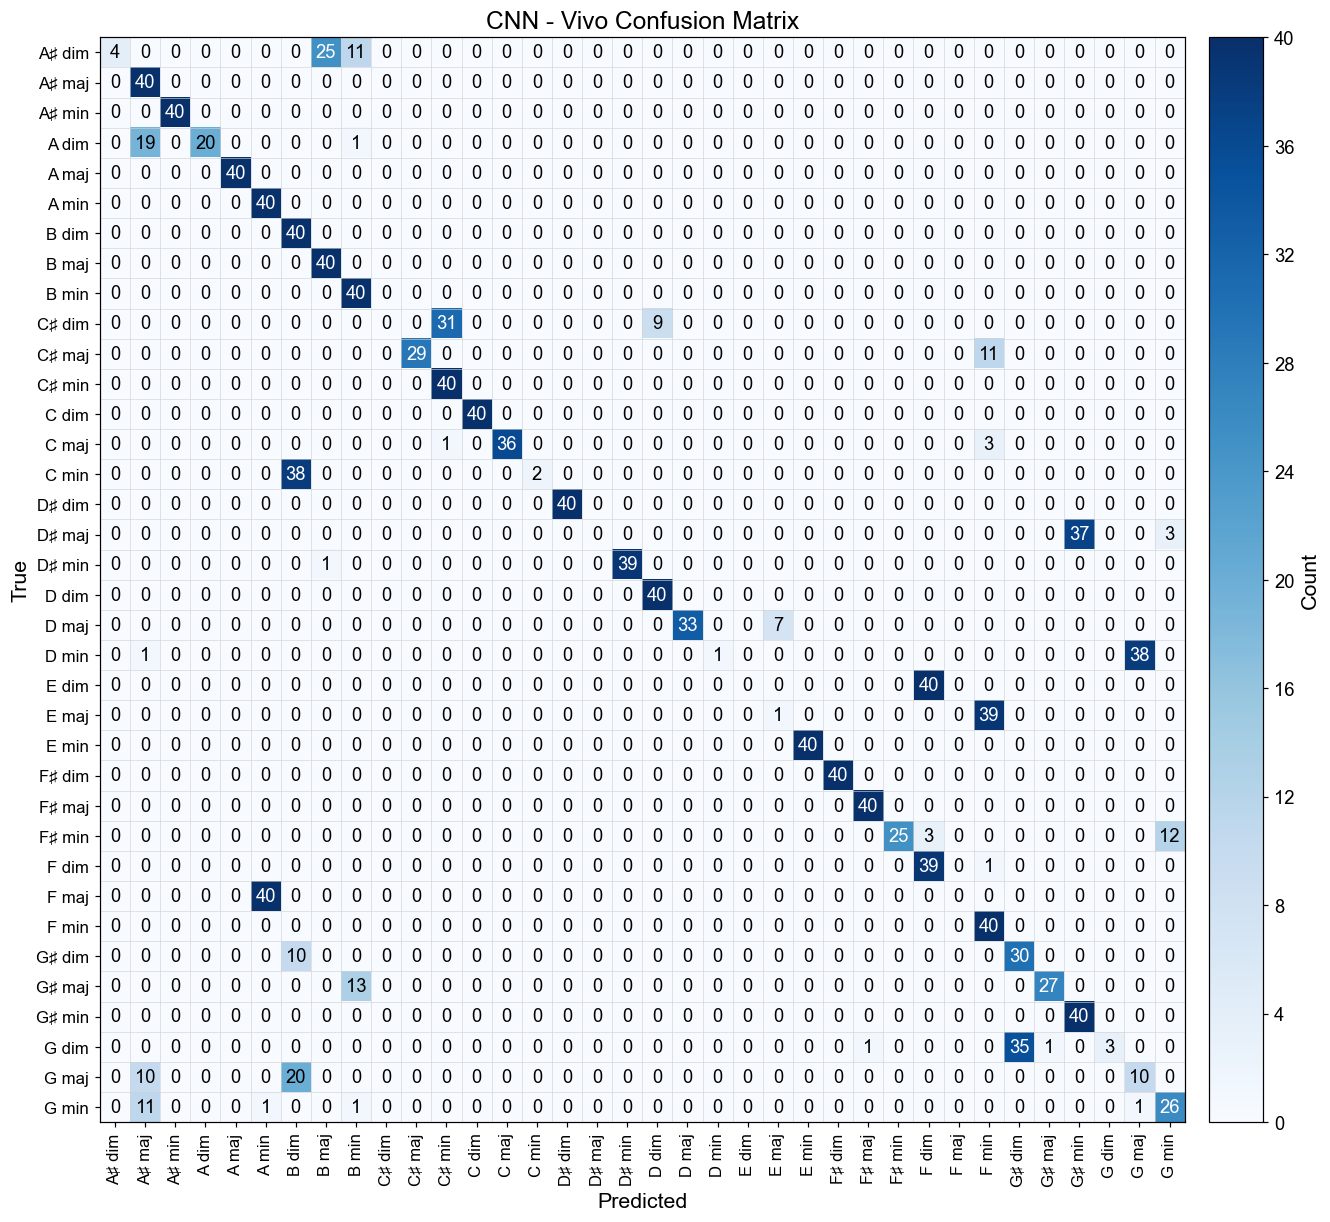

In [4]:
names = class_names()
show_cm("training", *training_cm())
for ds in OOD:
    cm = load_cm(ds)
    show_cm(ds, cm.loc[names, names].to_numpy(dtype=float), names)

## Evaluation metrics

Macro precision, recall, and F1 from the same clean run as the plots. Mean and std are over the rows above them.

In [20]:
from IPython.display import Markdown

METRIC_COLS = ["accuracy", "precision", "recall", "f1-score"]


def metrics_from_cm(mat, names):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
        recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
        denom = precision + recall
        f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    n = mat.sum()
    per_class = pd.DataFrame(
        {
            "class": [pretty_class(n) for n in names],
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "accuracy": recall,
            "support": support.astype(int),
        }
    )
    summary = {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(precision.mean()),
        "recall": float(recall.mean()),
        "f1-score": float(f1.mean()),
    }
    return per_class, summary


def with_mean_std(df, label_col):
    stats = pd.DataFrame(
        [
            {label_col: "mean", **df[METRIC_COLS].mean().to_dict()},
            {label_col: "std", **df[METRIC_COLS].std(ddof=1).to_dict()},
        ]
    )
    return pd.concat([df, stats], ignore_index=True)


def eval_items():
    names = class_names()
    items = [("training", *training_cm())]
    for ds in OOD:
        cm = load_cm(ds)
        items.append((ds, cm.loc[names, names].to_numpy(dtype=float), names))
    return items


rows = []
PER_CLASS = {}
for ds, mat, names in eval_items():
    per_class, summary = metrics_from_cm(mat, names)
    PER_CLASS[ds] = per_class
    rows.append({"evaluation": LABEL[ds], **summary})

summary_df = with_mean_std(pd.DataFrame(rows), "evaluation")
display(Markdown("### Recorded evaluations"))
display(summary_df.round(4))

### Recorded evaluations

,evaluation,accuracy,precision,recall,f1-score
0,Training,1.0000,1.0000,1.0000,1.0000
1,A1,0.8292,0.8533,0.8292,0.8164
2,A2,0.7111,0.6709,0.7111,0.6555
3,B1,0.9618,0.9734,0.9618,0.9609
4,B2,0.7382,0.7227,0.7382,0.6877
5,Vivo,0.6701,0.6869,0.6701,0.6041
6,mean,0.8184,0.8179,0.8184,0.7874
7,std,0.1368,0.1459,0.1368,0.1656


### K-fold

In [21]:
kf = pd.read_csv(RES / "kfold.csv")
kf = kf[kf.variant == "clean"].sort_values("fold")
kfold_df = pd.DataFrame(
    {
        "fold": [f"Fold {int(f) + 1}" for f in kf.fold],
        "accuracy": kf.test_accuracy.to_numpy(),
        "precision": kf.test_macro_precision.to_numpy(),
        "recall": kf.test_macro_recall.to_numpy(),
        "f1-score": kf.test_macro_f1.to_numpy(),
    }
)
display(with_mean_std(kfold_df, "fold").round(4))

,fold,accuracy,precision,recall,f1-score
0,Fold 1,1.0000,1.0000,1.0000,1.0000
1,Fold 2,1.0000,1.0000,1.0000,1.0000
2,Fold 3,0.9993,0.9993,0.9992,0.9993
3,Fold 4,1.0000,1.0000,1.0000,1.0000
4,Fold 5,1.0000,1.0000,1.0000,1.0000
5,mean,0.9999,0.9999,0.9998,0.9999
6,std,0.0003,0.0003,0.0003,0.0003


## Per-class metrics

Only classes with accuracy below 1.0. Precision and F1 are shown for those same rows.

In [22]:
cols = ["class", "precision", "recall", "f1-score", "accuracy", "support"]
for ds, per_class in PER_CLASS.items():
    imperfect = (
        per_class.loc[per_class.accuracy < 1.0, cols]
        .sort_values(["accuracy", "class"])
        .reset_index(drop=True)
    )
    display(Markdown(f"### {LABEL[ds]}"))
    if imperfect.empty:
        display(pd.DataFrame([{"note": "every class has accuracy 1.0"}]))
    else:
        display(imperfect.round(4))

### Training

,note
0,every class has accuracy 1.0


### A1

,class,precision,recall,f1-score,accuracy,support
0,D maj,0.0000,0.000,0.0000,0.000,40
1,E dim,0.0000,0.000,0.0000,0.000,40
2,F♯ min,0.1351,0.125,0.1299,0.125,40
3,C♯ maj,1.0000,0.250,0.4000,0.250,40
4,D♯ maj,1.0000,0.300,0.4615,0.300,40
5,D dim,0.6667,0.400,0.5000,0.400,40
6,F maj,1.0000,0.575,0.7302,0.575,40
7,B maj,1.0000,0.700,0.8235,0.700,40
8,A♯ maj,1.0000,0.775,0.8732,0.775,40
9,C♯ dim,1.0000,0.800,0.8889,0.800,40


### A2

...

,class,precision,recall,f1-score,accuracy,support
0,E dim,1.0000,0.475,0.6441,0.475,40
1,D maj,1.0000,0.550,0.7097,0.550,40
2,A maj,1.0000,0.875,0.9333,0.875,40
3,C♯ maj,1.0000,0.925,0.9610,0.925,40
4,D♯ maj,1.0000,0.925,0.9610,0.925,40
5,B maj,1.0000,0.950,0.9744,0.950,40
6,C maj,1.0000,0.975,0.9873,0.975,40
7,C♯ dim,1.0000,0.975,0.9873,0.975,40
8,G maj,0.8864,0.975,0.9286,0.975,40


### B2

,class,precision,recall,f1-score,accuracy,support
0,A♯ dim,0.0000,0.000,0.0000,0.000,40
1,C♯ maj,0.0000,0.000,0.0000,0.000,40
2,D maj,0.0000,0.000,0.0000,0.000,40
3,G♯ dim,0.0000,0.000,0.0000,0.000,40
4,D min,1.0000,0.025,0.0488,0.025,40
5,G maj,0.0833,0.025,0.0385,0.025,40
6,G min,0.6000,0.150,0.2400,0.150,40
7,C♯ min,1.0000,0.400,0.5714,0.400,40
8,D dim,1.0000,0.425,0.5965,0.425,40
9,E dim,0.9286,0.650,0.7647,0.650,40


### Vivo

,class,precision,recall,f1-score,accuracy,support
0,C♯ dim,0.0000,0.000,0.0000,0.000,40
1,D♯ maj,0.0000,0.000,0.0000,0.000,40
2,E dim,0.0000,0.000,0.0000,0.000,40
3,F maj,0.0000,0.000,0.0000,0.000,40
4,D min,1.0000,0.025,0.0488,0.025,40
5,E maj,0.1250,0.025,0.0417,0.025,40
6,C min,1.0000,0.050,0.0952,0.050,40
7,G dim,1.0000,0.075,0.1395,0.075,40
8,A♯ dim,1.0000,0.100,0.1818,0.100,40
9,G maj,0.2041,0.250,0.2247,0.250,40
